# Analyse des données – Mémoire de Master
## Appropriation des Points Numériques Communautaires (PNC) dans les Collines
### Analyse comparative des communes de Dassa-Zoumè, Glazoué et Savè (Bénin)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Style général ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})
COMMUNE_COLORS = {
    'Dassa-Zoume': '#2196F3',
    'Glazoue':     '#4CAF50',
    'Save':        '#FF9800',
}
COMMUNES = ['Dassa-Zoume', 'Glazoue', 'Save']

# ── Chargement des données ─────────────────────────────────────────────────────
FILE = 'Préparation du traitement .xlsx'
df = pd.read_excel(FILE, sheet_name='Données questionnaire')

# Renommage des colonnes pour faciliter l'accès
df.columns = [
    'sexe','age','niveau_etudes','profession','commune',
    'smartphone','smartphone_internet',
    'connait_pnc','utilise_pnc',
    'frequence','duree_utilisation','heures_visite','raisons_utilisation','raisons_non_utilisation',
    'formation','formation_autonomie','niveau_tic','experience_internet',
    'peut_mail','peut_paiement','peut_telechargement',
    'qualite_connexion','suffisance_ordi','etat_materiel','horaires_adaptes',
    'services_payants','tarifs_abordables','agent_present','agent_competent',
    'aide_demarches','ameliore_opportunites','satisfaction','recommande',
    'obstacles','suggestions'
]

# Groupes d'âge
bins   = [0, 19, 29, 39, 49, 59, 200]
labels = ['< 20 ans', '20-29 ans', '30-39 ans', '40-49 ans', '50-59 ans', '≥ 60 ans']
df['groupe_age'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

print(f"Base de données chargée : {len(df)} répondants")
print(df['commune'].value_counts().to_string())

# ── Variable composite : Appropriation du PNC ─────────────────────────────────
# L'appropriation est définie par la réunion des quatre conditions :
#   1. Fréquence d'utilisation moyenne ou élevée
#   2. Niveau de compétences numériques (niveau_tic ≥ 3)
#   3. Autonomie numérique (peut envoyer mail OU payer en ligne OU télécharger/installer)
#   4. Satisfaction du PNC
df['freq_ok']  = df['frequence'].isin(['Moyen', 'Elevé'])
df['comp_ok']  = df['niveau_tic'] >= 3
df['auto_ok']  = ((df['peut_mail']=='Oui') |
                   (df['peut_paiement']=='Oui') |
                   (df['peut_telechargement']=='Oui'))
df['satis_ok'] = df['satisfaction'] == 'Oui'
df['appropriation'] = np.where(
    df['freq_ok'] & df['comp_ok'] & df['auto_ok'] & df['satis_ok'], 'Oui', 'Non'
)

print("\nVariable composite Appropriation du PNC :")
print(df['appropriation'].value_counts().to_string())
print("\nTaux d'appropriation par commune :")
print(
    df.groupby('commune')['appropriation']
      .apply(lambda x: f"{(x=='Oui').sum()}/{len(x)} ({(x=='Oui').mean()*100:.1f}%)")
      .to_string()
)


Base de données chargée : 400 répondants
commune
Glazoue        155
Save           133
Dassa-Zoume    112

Variable composite Appropriation du PNC :
appropriation
Non    357
Oui     43

Taux d'appropriation par commune :
commune
Dassa-Zoume     11/112 (9.8%)
Glazoue        20/155 (12.9%)
Save            12/133 (9.0%)


---
## SECTION 1 : Caractéristiques socio-démographiques (ensemble des trois communes)

In [2]:
# ── Tableau 1 – Caractéristiques socio-démographiques (ensemble) ───────────────
def freq_table(series, label):
    vc = series.value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    tbl = pd.DataFrame({'Modalité': vc.index, 'Effectif': vc.values, '%': pct.values})
    tbl.insert(0, 'Variable', '')
    tbl.iloc[0, 0] = label
    return tbl

parts = [
    freq_table(df['sexe'], 'Sexe'),
    freq_table(df['groupe_age'], 'Groupe d\'âge'),
    freq_table(df['niveau_etudes'], 'Niveau d\'études'),
    freq_table(df['profession'], 'Profession'),
]
tableau_socio = pd.concat(parts, ignore_index=True)
tableau_socio['%'] = tableau_socio['%'].map(lambda x: f"{x:.1f} %")

print("Tableau 1 – Caractéristiques socio-démographiques de l'échantillon (n = 400)")
print("=" * 60)
print(tableau_socio.to_string(index=False))

Tableau 1 – Caractéristiques socio-démographiques de l'échantillon (n = 400)
       Variable      Modalité  Effectif      %
           Sexe             M       217 54.2 %
                            F       183 45.8 %
   Groupe d'âge     30-39 ans       119 29.8 %
                    20-29 ans       100 25.0 %
                    40-49 ans        91 22.8 %
                    50-59 ans        60 15.0 %
                     < 20 ans        30  7.5 %
                     ≥ 60 ans         0  0.0 %
Niveau d'études     Supérieur       189 47.2 %
                   Secondaire       132 33.0 %
                     Primaire        79 19.8 %
     Profession       Artisan        87 21.8 %
                   Commercant        81 20.2 %
                Fonctionnaire        66 16.5 %
                     Etudiant        66 16.5 %
                  Sans emploi        63 15.8 %
                        Eleve        37  9.2 %


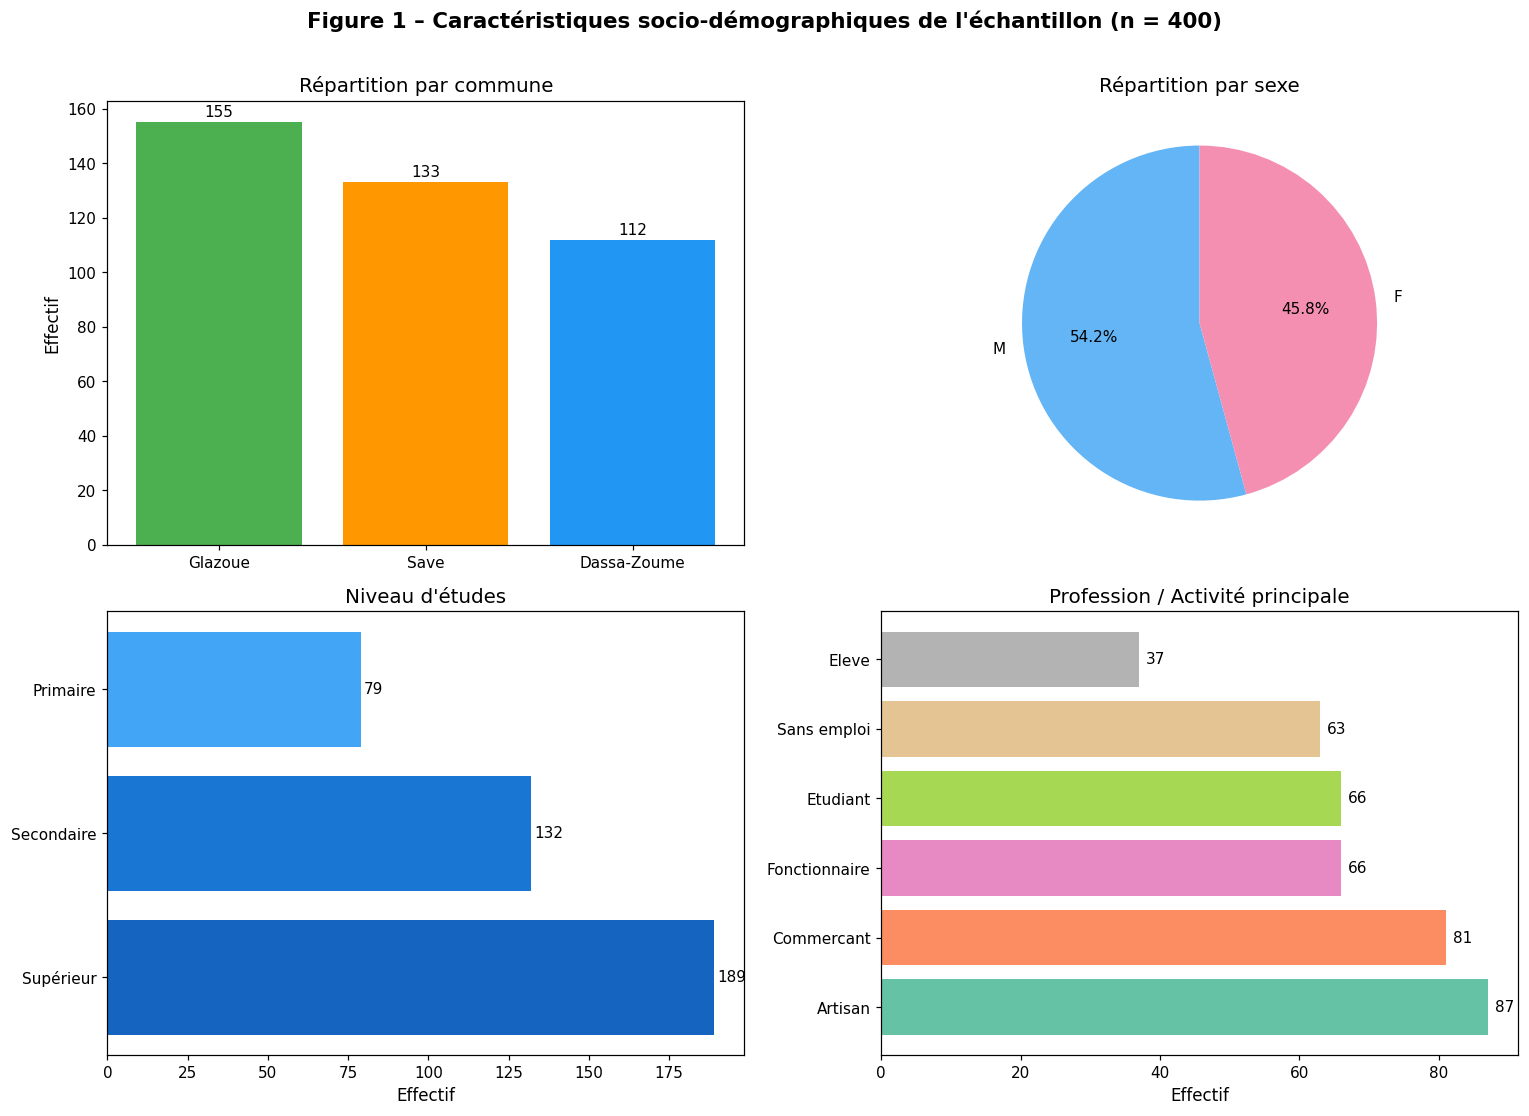

In [3]:
# ── Figure 1 – Répartition par commune, sexe, niveau d'études et profession ────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figure 1 – Caractéristiques socio-démographiques de l'échantillon (n = 400)",
             fontsize=14, fontweight='bold', y=1.01)

# Commune
vc = df['commune'].value_counts()
axes[0, 0].bar(vc.index, vc.values,
               color=[COMMUNE_COLORS[c] for c in vc.index])
axes[0, 0].set_title('Répartition par commune')
axes[0, 0].set_ylabel('Effectif')
for i, v in enumerate(vc.values):
    axes[0, 0].text(i, v + 2, str(v), ha='center', fontsize=10)

# Sexe
vc_sexe = df['sexe'].value_counts()
axes[0, 1].pie(vc_sexe.values, labels=vc_sexe.index, autopct='%1.1f%%',
               colors=['#64B5F6', '#F48FB1'], startangle=90)
axes[0, 1].set_title('Répartition par sexe')

# Niveau d'études
vc_niv = df['niveau_etudes'].value_counts()
colors_niv = ['#1565C0', '#1976D2', '#42A5F5']
axes[1, 0].barh(vc_niv.index, vc_niv.values, color=colors_niv)
axes[1, 0].set_title("Niveau d'études")
axes[1, 0].set_xlabel('Effectif')
for i, v in enumerate(vc_niv.values):
    axes[1, 0].text(v + 1, i, str(v), va='center', fontsize=10)

# Profession
vc_pro = df['profession'].value_counts()
colors_pro = plt.cm.Set2(np.linspace(0, 1, len(vc_pro)))
axes[1, 1].barh(vc_pro.index, vc_pro.values, color=colors_pro)
axes[1, 1].set_title('Profession / Activité principale')
axes[1, 1].set_xlabel('Effectif')
for i, v in enumerate(vc_pro.values):
    axes[1, 1].text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figure1_Caracteristiques_sociodemo.png', bbox_inches='tight')
plt.show()

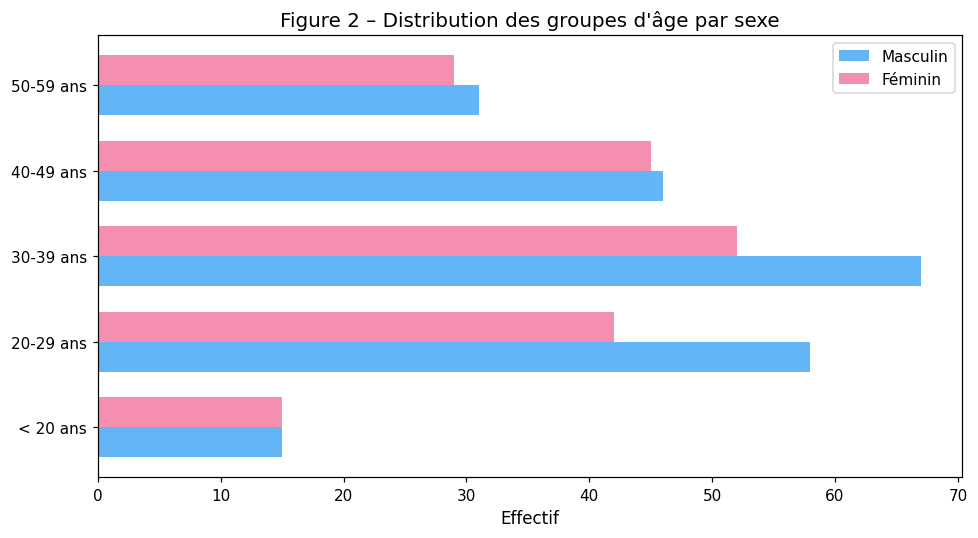

In [4]:
# ── Figure 2 – Pyramide des âges (groupe d'âge × sexe) ────────────────────────
age_sexe = df.groupby(['groupe_age', 'sexe'], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(age_sexe))
w = 0.35
ax.barh(y - w/2, age_sexe.get('M', pd.Series(0, index=age_sexe.index)),
        height=w, color='#64B5F6', label='Masculin')
ax.barh(y + w/2, age_sexe.get('F', pd.Series(0, index=age_sexe.index)),
        height=w, color='#F48FB1', label='Féminin')
ax.set_yticks(y)
ax.set_yticklabels(age_sexe.index)
ax.set_xlabel('Effectif')
ax.set_title("Figure 2 – Distribution des groupes d'âge par sexe")
ax.legend()
plt.tight_layout()
plt.savefig('Figure2_Groupes_age_sexe.png', bbox_inches='tight')
plt.show()

---
## SECTION 2 : Appréciation du niveau d'accessibilité, d'usage et d'appropriation du PNC par commune

In [5]:
def crosstab_pct(df, var, commune_col='commune'):
    """Tableau croisé variable × commune avec effectifs et pourcentages."""
    ct = pd.crosstab(df[var], df[commune_col], margins=True, margins_name='Total')
    pct = pd.crosstab(df[var], df[commune_col], normalize='columns').mul(100).round(1)
    # Colonnes communes (sans Total)
    comm_cols = [c for c in ct.columns if c != 'Total']
    row_idx   = [i for i in ct.index  if i != 'Total']
    # Lignes de données : n (%)
    combined = ct.loc[row_idx, comm_cols].astype(str) + ' (' + pct.loc[row_idx, comm_cols].astype(str) + '%)'
    # Colonne Total des lignes de données : global %
    global_pct = (ct.loc[row_idx, 'Total'] / len(df) * 100).round(1)
    combined['Total'] = ct.loc[row_idx, 'Total'].astype(str) + ' (' + global_pct.astype(str) + '%)'
    # Ligne Total : effectifs seulement
    combined.loc['Total'] = ct.loc['Total'].astype(str)
    return combined



def plot_bar_commune(df, var, title, xlabel='', ylabel='% des répondants', dropna=True):
    """Graphique en barres groupées par commune."""
    data = df.copy()
    if dropna:
        data = data.dropna(subset=[var])
    pct = data.groupby(['commune', var]).size().unstack(fill_value=0)
    pct = pct.div(pct.sum(axis=1), axis=0).mul(100).round(1)
    ax = pct.plot(kind='bar', figsize=(10, 5), width=0.65,
                  color=plt.cm.Set1(np.linspace(0, 0.8, pct.shape[1])))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)
    plt.tight_layout()
    return ax

Tableau 2 – Possession de smartphone avec accès Internet par commune
commune             Dassa-Zoume     Glazoue        Save        Total
smartphone_internet                                                 
Non                  53 (47.3%)  80 (51.6%)  72 (54.1%)  205 (51.2%)
Oui                  59 (52.7%)  75 (48.4%)  61 (45.9%)  195 (48.8%)
Total                       112         155         133          400



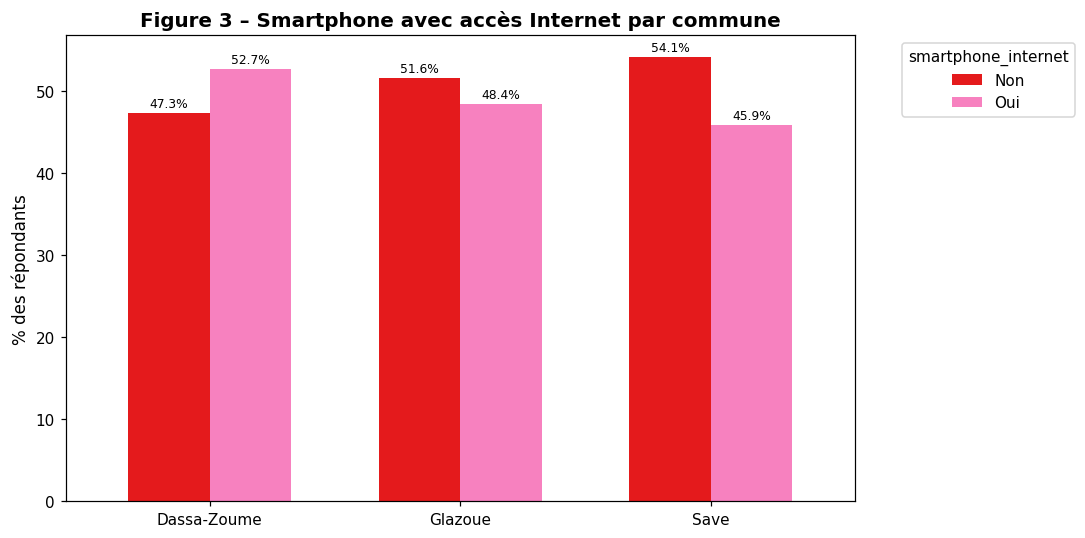

In [6]:
# ── Tableau 2 – Accès au smartphone et à Internet par commune ──────────────────
print("Tableau 2 – Possession de smartphone avec accès Internet par commune")
print(crosstab_pct(df, 'smartphone_internet').to_string())
print()

ax = plot_bar_commune(df, 'smartphone_internet',
    'Figure 3 – Smartphone avec accès Internet par commune')
plt.savefig('Figure3_Smartphone_internet.png', bbox_inches='tight')
plt.show()

Tableau 3 – Usage du PNC par commune
commune     Dassa-Zoume     Glazoue        Save        Total
utilise_pnc                                                 
Non          55 (49.1%)  77 (49.7%)  66 (49.6%)  198 (49.5%)
Oui          57 (50.9%)  78 (50.3%)  67 (50.4%)  202 (50.5%)
Total               112         155         133          400



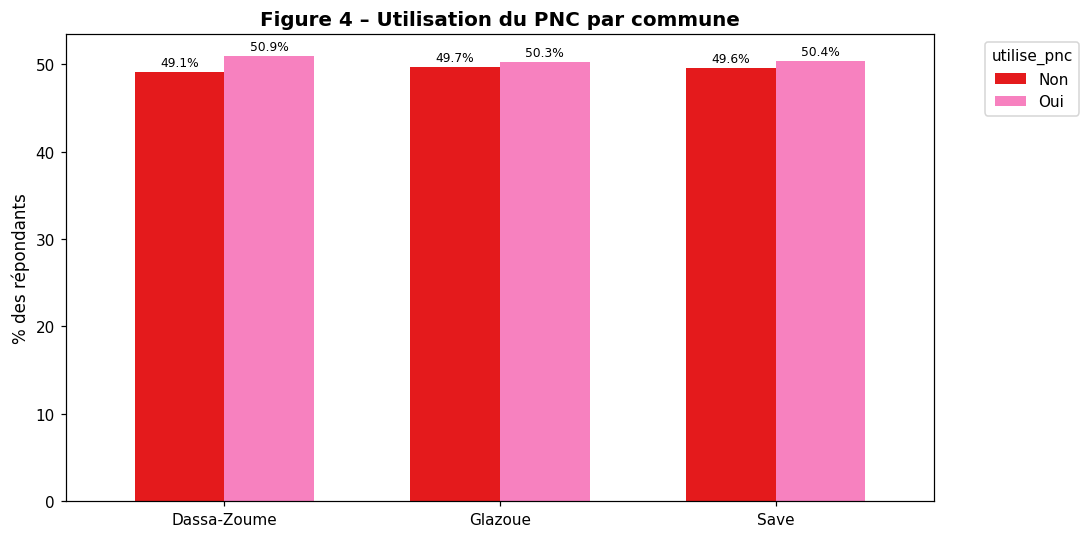

In [7]:
# ── Tableau 3 – Usage du PNC par commune ──────────────────────────────────────
print("Tableau 3 – Usage du PNC par commune")
print(crosstab_pct(df, 'utilise_pnc').to_string())
print()

ax = plot_bar_commune(df, 'utilise_pnc',
    'Figure 4 – Utilisation du PNC par commune')
plt.savefig('Figure4_Utilisation_PNC.png', bbox_inches='tight')
plt.show()

Sous-groupe usagers : n = 202

Tableau 4 – Fréquence d'utilisation du PNC par commune (usagers uniquement)
commune   Dassa-Zoume     Glazoue        Save       Total
frequence                                                
Elevé      12 (21.1%)  25 (32.1%)  29 (43.3%)  66 (32.7%)
Faible     22 (38.6%)  21 (26.9%)  18 (26.9%)  61 (30.2%)
Moyen      23 (40.4%)  32 (41.0%)  20 (29.9%)  75 (37.1%)
Total              57          78          67         202


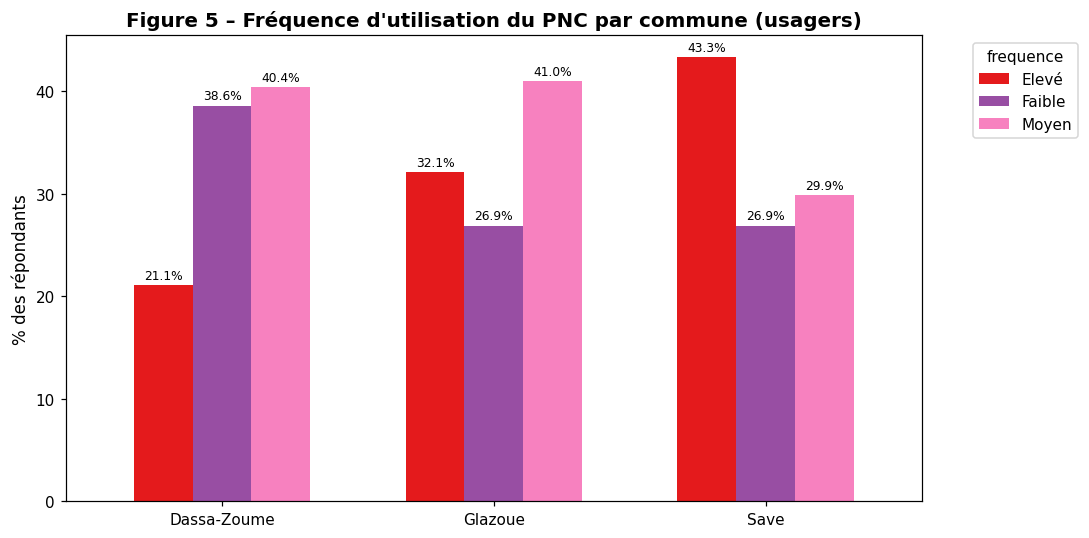

In [8]:
# ── Tableau 4 – Fréquence d'utilisation (usagers seulement) par commune ────────
df_usagers = df[df['utilise_pnc'] == 'Oui'].copy()
print(f"Sous-groupe usagers : n = {len(df_usagers)}")
print()
print("Tableau 4 – Fréquence d'utilisation du PNC par commune (usagers uniquement)")
print(crosstab_pct(df_usagers, 'frequence').to_string())

ax = plot_bar_commune(df_usagers, 'frequence',
    'Figure 5 – Fréquence d\'utilisation du PNC par commune (usagers)')
plt.savefig('Figure5_Frequence_utilisation.png', bbox_inches='tight')
plt.show()

Tableau 5 – Durée d'utilisation régulière du PNC par commune (usagers)
commune           Dassa-Zoume     Glazoue        Save       Total
duree_utilisation                                                
1 an               17 (29.8%)  26 (33.3%)  30 (44.8%)  73 (36.1%)
2 ans              20 (35.1%)  26 (33.3%)  17 (25.4%)  63 (31.2%)
<6 mois            20 (35.1%)  26 (33.3%)  20 (29.9%)  66 (32.7%)
Total                      57          78          67         202


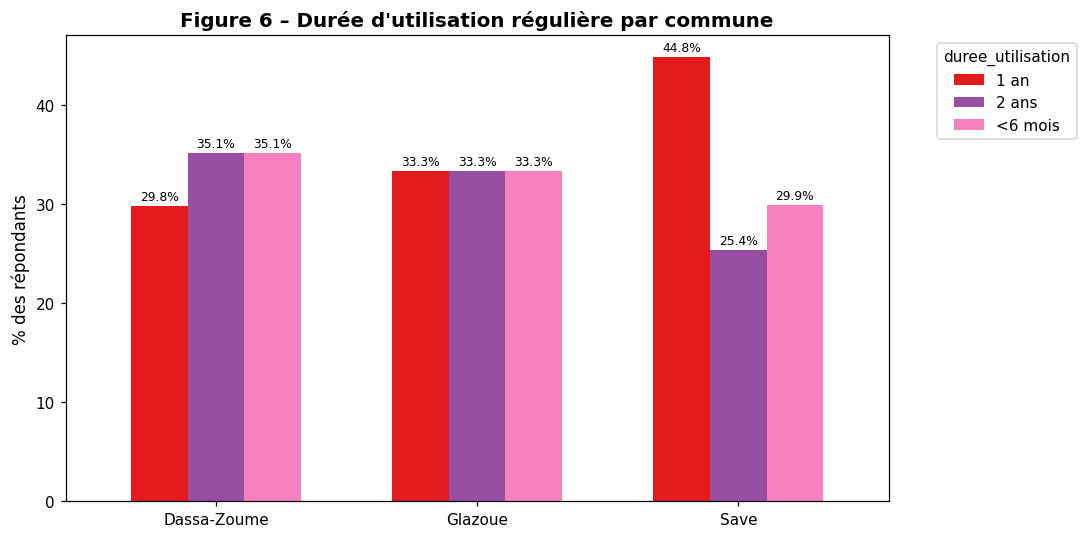

In [9]:
# ── Tableau 5 – Durée d'utilisation régulière par commune ─────────────────────
print("Tableau 5 – Durée d'utilisation régulière du PNC par commune (usagers)")
print(crosstab_pct(df_usagers, 'duree_utilisation').to_string())

ax = plot_bar_commune(df_usagers, 'duree_utilisation',
    'Figure 6 – Durée d\'utilisation régulière par commune')
plt.savefig('Figure6_Duree_utilisation.png', bbox_inches='tight')
plt.show()

Tableau 6 – Raisons d'utilisation du PNC par commune (usagers)
commune             Dassa-Zoume     Glazoue        Save       Total
raisons_utilisation                                                
Communication        13 (22.8%)  29 (37.2%)  23 (34.3%)  65 (32.2%)
Formation            20 (35.1%)  21 (26.9%)  20 (29.9%)  61 (30.2%)
Recherche            24 (42.1%)  28 (35.9%)  24 (35.8%)  76 (37.6%)
Total                        57          78          67         202


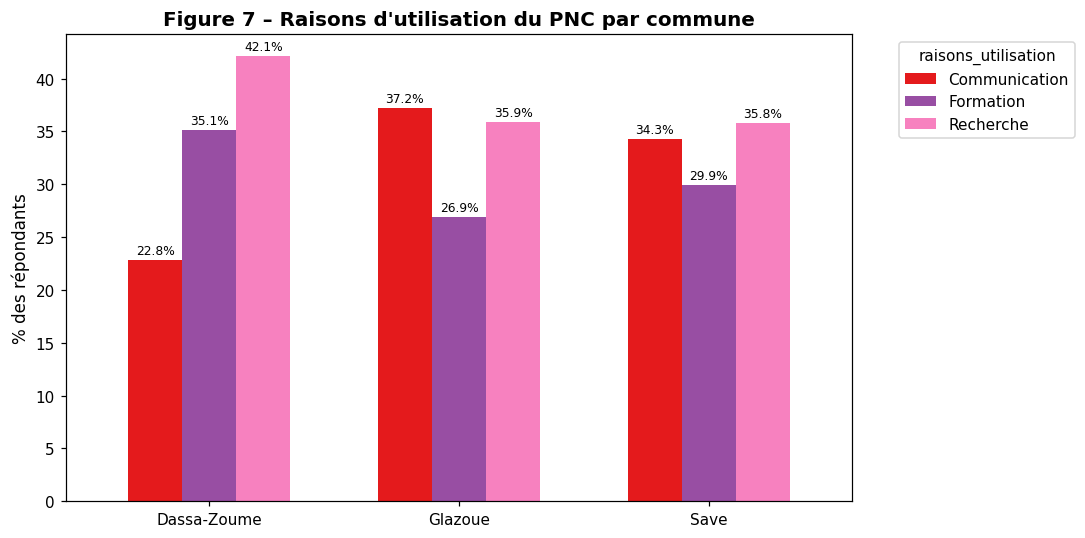

In [10]:
# ── Tableau 6 – Raisons d'utilisation par commune ─────────────────────────────
print("Tableau 6 – Raisons d'utilisation du PNC par commune (usagers)")
print(crosstab_pct(df_usagers, 'raisons_utilisation').to_string())

ax = plot_bar_commune(df_usagers, 'raisons_utilisation',
    'Figure 7 – Raisons d\'utilisation du PNC par commune')
plt.savefig('Figure7_Raisons_utilisation.png', bbox_inches='tight')
plt.show()

In [11]:
# ── Tableau 7 – Raisons de non-utilisation par commune ────────────────────────
df_non_usagers = df[df['utilise_pnc'] == 'Non'].copy()
print("Tableau 7 – Raisons de non-utilisation du PNC par commune (non-usagers)")
print(crosstab_pct(df_non_usagers, 'raisons_non_utilisation').to_string())

Tableau 7 – Raisons de non-utilisation du PNC par commune (non-usagers)
commune                  Dassa-Zoume      Glazoue         Save         Total
raisons_non_utilisation                                                     
Manque de temps          55 (100.0%)  77 (100.0%)  66 (100.0%)  198 (100.0%)
Total                             55           77           66           198


---
## SECTION 3 : Appréciation de la formation et du niveau de compétences des usagers par commune

Tableau 8 – Formation au PNC par commune
commune   Dassa-Zoume     Glazoue        Save        Total
formation                                                 
Non        58 (51.8%)  79 (51.0%)  71 (53.4%)  208 (52.0%)
Oui        54 (48.2%)  76 (49.0%)  62 (46.6%)  192 (48.0%)
Total             112         155         133          400


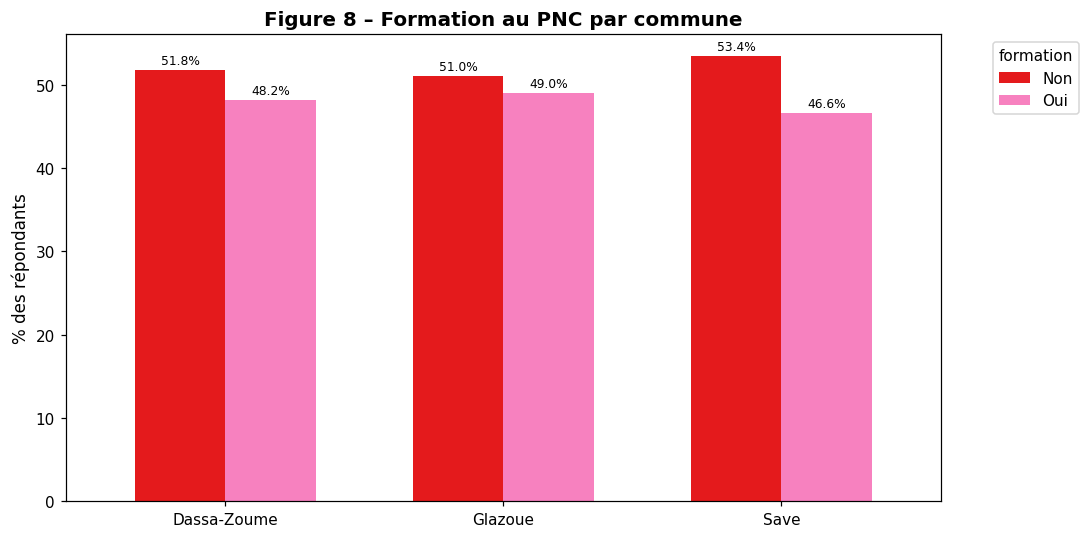

In [12]:
# ── Tableau 8 – Formation au PNC par commune ──────────────────────────────────
print("Tableau 8 – Formation au PNC par commune")
print(crosstab_pct(df, 'formation').to_string())

ax = plot_bar_commune(df, 'formation',
    'Figure 8 – Formation au PNC par commune')
plt.savefig('Figure8_Formation.png', bbox_inches='tight')
plt.show()

Sous-groupe formés : n = 192

Tableau 9 – Impact de la formation sur l'autonomie numérique par commune
commune             Dassa-Zoume     Glazoue        Save        Total
formation_autonomie                                                 
Non                  25 (46.3%)  31 (40.8%)  29 (46.8%)   85 (44.3%)
Oui                  29 (53.7%)  45 (59.2%)  33 (53.2%)  107 (55.7%)
Total                        54          76          62          192


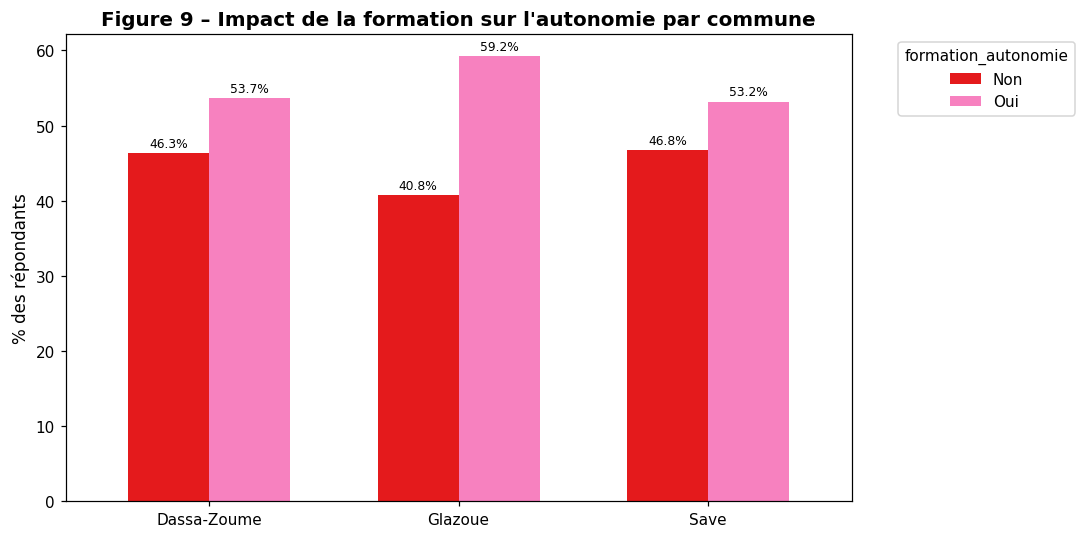

In [13]:
# ── Tableau 9 – Impact de la formation sur l'autonomie par commune ─────────────
df_formes = df[df['formation'] == 'Oui'].copy()
print(f"Sous-groupe formés : n = {len(df_formes)}")
print()
print("Tableau 9 – Impact de la formation sur l'autonomie numérique par commune")
print(crosstab_pct(df_formes, 'formation_autonomie').to_string())

ax = plot_bar_commune(df_formes, 'formation_autonomie',
    'Figure 9 – Impact de la formation sur l\'autonomie par commune')
plt.savefig('Figure9_Impact_formation.png', bbox_inches='tight')
plt.show()

In [14]:
# ── Tableau 10 – Niveau TIC moyen par commune ─────────────────────────────────
tic_commune = df.groupby('commune')['niveau_tic'].agg(['mean', 'median', 'std']).round(2)
tic_commune.columns = ['Moyenne', 'Médiane', 'Écart-type']
print("Tableau 10 – Niveau TIC moyen par commune (échelle 1 à 5)")
print(tic_commune.to_string())
print(f"\nNiveau TIC moyen global : {df['niveau_tic'].mean():.2f}")

Tableau 10 – Niveau TIC moyen par commune (échelle 1 à 5)
             Moyenne  Médiane  Écart-type
commune                                  
Dassa-Zoume     3.04      3.0        1.34
Glazoue         3.13      3.0        1.41
Save            2.89      3.0        1.37

Niveau TIC moyen global : 3.02


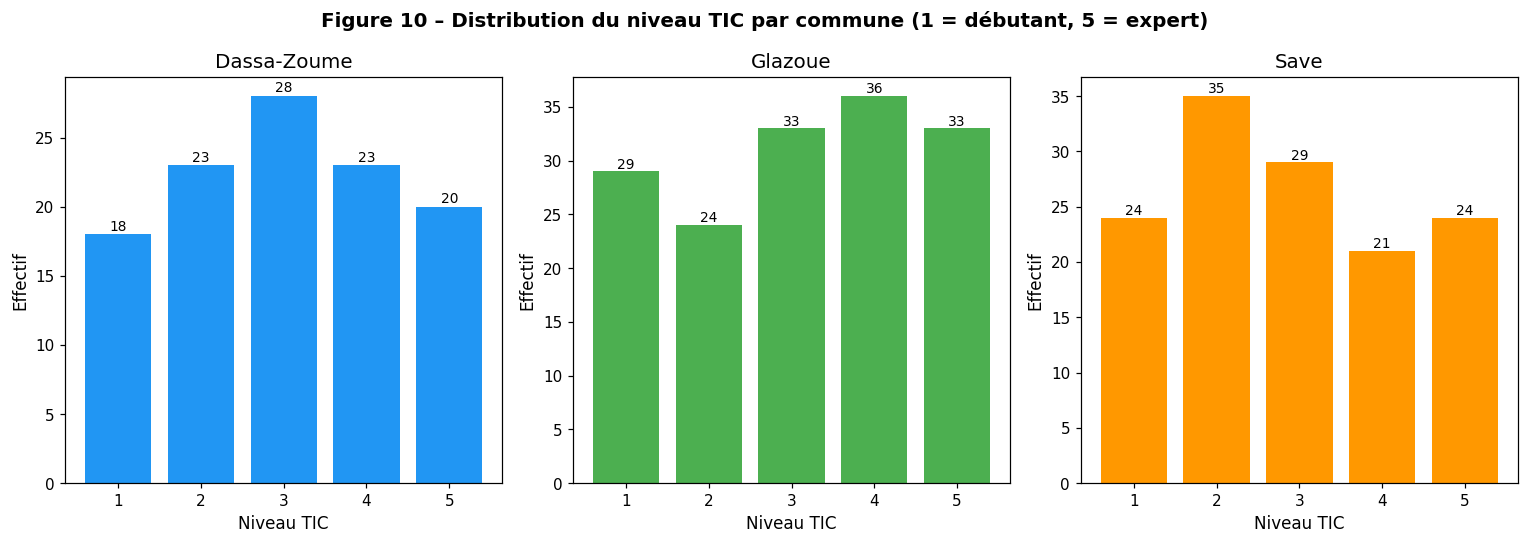

In [15]:
# ── Figure 10 – Distribution du niveau TIC par commune ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle("Figure 10 – Distribution du niveau TIC par commune (1 = débutant, 5 = expert)",
             fontsize=13, fontweight='bold')

for ax, commune in zip(axes, COMMUNES):
    data_c = df[df['commune'] == commune]['niveau_tic'].value_counts().sort_index()
    ax.bar(data_c.index, data_c.values, color=COMMUNE_COLORS[commune])
    ax.set_title(commune)
    ax.set_xlabel('Niveau TIC')
    ax.set_ylabel('Effectif')
    ax.set_xticks([1, 2, 3, 4, 5])
    for xi, yi in zip(data_c.index, data_c.values):
        ax.text(xi, yi + 0.3, str(yi), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('Figure10_Niveau_TIC.png', bbox_inches='tight')
plt.show()

In [16]:
# ── Tableau 11 – Expérience préalable Internet et compétences autonomes ─────────
print("Tableau 11 – Expérience préalable Internet par commune")
print(crosstab_pct(df, 'experience_internet').to_string())
print()

competences = {
    'Envoi d\'un e-mail':    'peut_mail',
    'Paiement en ligne':    'peut_paiement',
    'Téléchargement / App': 'peut_telechargement',
}
print("Tableau 12 – Compétences numériques autonomes par commune")
print("="*70)
rows = []
for label, col in competences.items():
    ct_pct = pd.crosstab(df['commune'], df[col], normalize='index').mul(100).round(1)
    for mod in ct_pct.columns:
        rows.append({'Compétence': label, 'Réponse': mod,
                     **{c: f"{ct_pct.loc[c, mod]:.1f}%" for c in COMMUNES}})
tbl12 = pd.DataFrame(rows)
print(tbl12.to_string(index=False))

Tableau 11 – Expérience préalable Internet par commune
commune             Dassa-Zoume     Glazoue        Save        Total
experience_internet                                                 
Non                  63 (56.2%)  88 (56.8%)  68 (51.1%)  219 (54.8%)
Oui                  49 (43.8%)  67 (43.2%)  65 (48.9%)  181 (45.2%)
Total                       112         155         133          400

Tableau 12 – Compétences numériques autonomes par commune
          Compétence Réponse Dassa-Zoume Glazoue  Save
   Envoi d'un e-mail     Non       53.6%   53.5% 50.4%
   Envoi d'un e-mail     Oui       46.4%   46.5% 49.6%
   Paiement en ligne     Non       43.8%   51.0% 49.6%
   Paiement en ligne     Oui       56.2%   49.0% 50.4%
Téléchargement / App     Non       44.6%   46.5% 51.1%
Téléchargement / App     Oui       55.4%   53.5% 48.9%


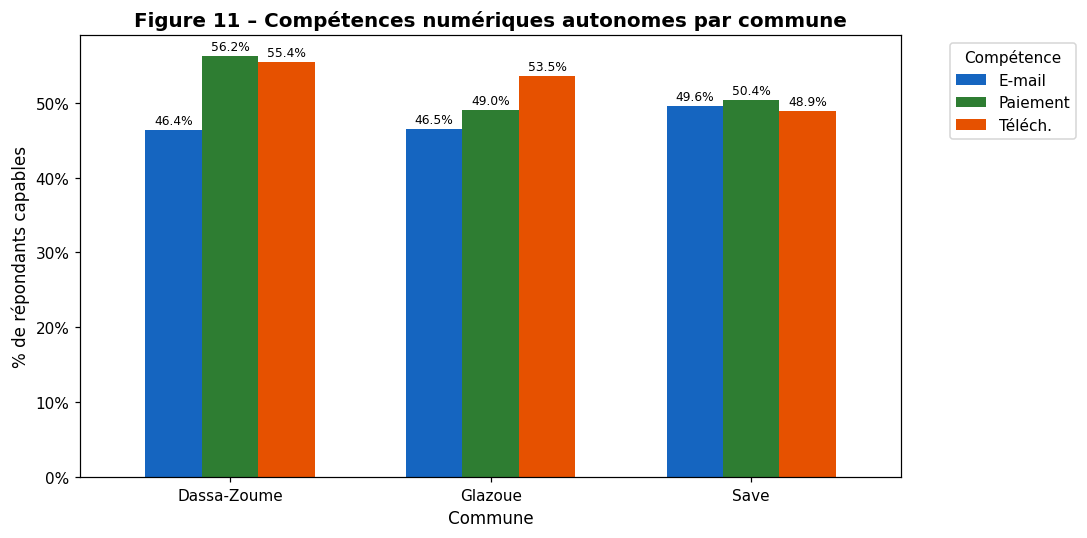

In [17]:
# ── Figure 11 – Compétences numériques autonomes par commune ──────────────────
comp_cols = ['peut_mail', 'peut_paiement', 'peut_telechargement']
comp_labels = ['E-mail', 'Paiement', 'Téléch.']
pct_oui = df.groupby('commune')[comp_cols].apply(
    lambda g: (g == 'Oui').mean() * 100
).round(1)
pct_oui.columns = comp_labels

ax = pct_oui.plot(kind='bar', figsize=(10, 5), width=0.65,
                  color=['#1565C0', '#2E7D32', '#E65100'])
ax.set_title("Figure 11 – Compétences numériques autonomes par commune",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Commune')
ax.set_ylabel('% de répondants capables')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Compétence', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('Figure11_Competences_numeriques.png', bbox_inches='tight')
plt.show()

---
## SECTION 4 : Appréciation de la qualité des services du PNC par commune

Tableau 13 – Qualité de la connexion Internet par commune (échelle 1 à 5)
             Moyenne  Médiane  Écart-type
commune                                  
Dassa-Zoume     2.69      2.0        1.38
Glazoue         2.90      3.0        1.44
Save            3.15      3.0        1.46


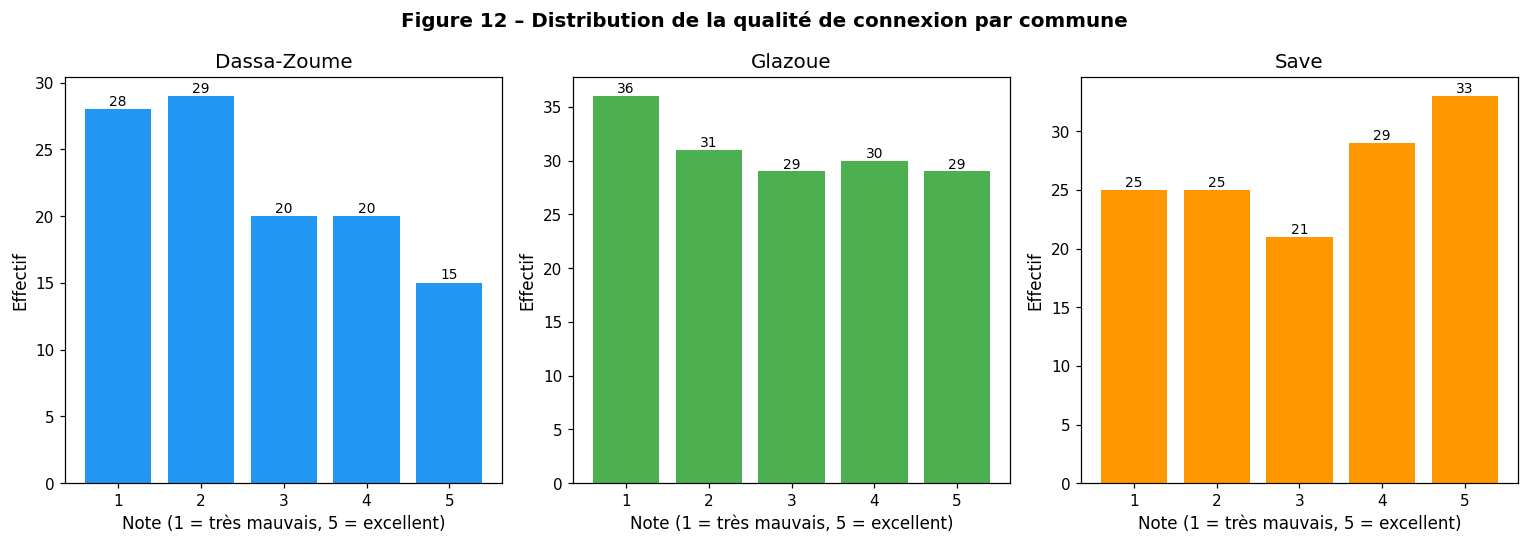

In [18]:
# ── Tableau 13 – Qualité de connexion moyenne par commune ─────────────────────
conn_stats = df.groupby('commune')['qualite_connexion'].agg(['mean','median','std']).round(2)
conn_stats.columns = ['Moyenne','Médiane','Écart-type']
print("Tableau 13 – Qualité de la connexion Internet par commune (échelle 1 à 5)")
print(conn_stats.to_string())

# Distribution par commune
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle("Figure 12 – Distribution de la qualité de connexion par commune",
             fontsize=13, fontweight='bold')
for ax, commune in zip(axes, COMMUNES):
    data_c = df[df['commune'] == commune]['qualite_connexion'].value_counts().sort_index()
    ax.bar(data_c.index, data_c.values, color=COMMUNE_COLORS[commune])
    ax.set_title(commune)
    ax.set_xlabel('Note (1 = très mauvais, 5 = excellent)')
    ax.set_ylabel('Effectif')
    ax.set_xticks([1, 2, 3, 4, 5])
    for xi, yi in zip(data_c.index, data_c.values):
        ax.text(xi, yi + 0.3, str(yi), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('Figure12_Qualite_connexion.png', bbox_inches='tight')
plt.show()

In [19]:
# ── Tableaux 14-19 – Indicateurs de service par commune ───────────────────────
service_vars = {
    'suffisance_ordi':   'Tableau 14 – Suffisance des ordinateurs par commune',
    'etat_materiel':     'Tableau 15 – État du matériel par commune',
    'horaires_adaptes':  'Tableau 16 – Adaptation des horaires par commune',
    'services_payants':  'Tableau 17 – Existence de services payants par commune',
    'tarifs_abordables': 'Tableau 18 – Abordabilité des tarifs par commune',
    'agent_present':     'Tableau 19 – Présence d\'un agent par commune',
    'agent_competent':   'Tableau 20 – Compétence de l\'agent par commune',
}

for col, title in service_vars.items():
    print(title)
    print(crosstab_pct(df, col).to_string())
    print()

Tableau 14 – Suffisance des ordinateurs par commune
commune         Dassa-Zoume     Glazoue        Save        Total
suffisance_ordi                                                 
Non              50 (44.6%)  79 (51.0%)  63 (47.4%)  192 (48.0%)
Oui              62 (55.4%)  76 (49.0%)  70 (52.6%)  208 (52.0%)
Total                   112         155         133          400

Tableau 15 – État du matériel par commune
commune       Dassa-Zoume     Glazoue        Save        Total
etat_materiel                                                 
Non            47 (42.0%)  80 (51.6%)  61 (45.9%)  188 (47.0%)
Oui            65 (58.0%)  75 (48.4%)  72 (54.1%)  212 (53.0%)
Total                 112         155         133          400

Tableau 16 – Adaptation des horaires par commune
commune          Dassa-Zoume     Glazoue        Save        Total
horaires_adaptes                                                 
Non               57 (50.9%)  75 (48.4%)  73 (54.9%)  205 (51.2%)
Oui              

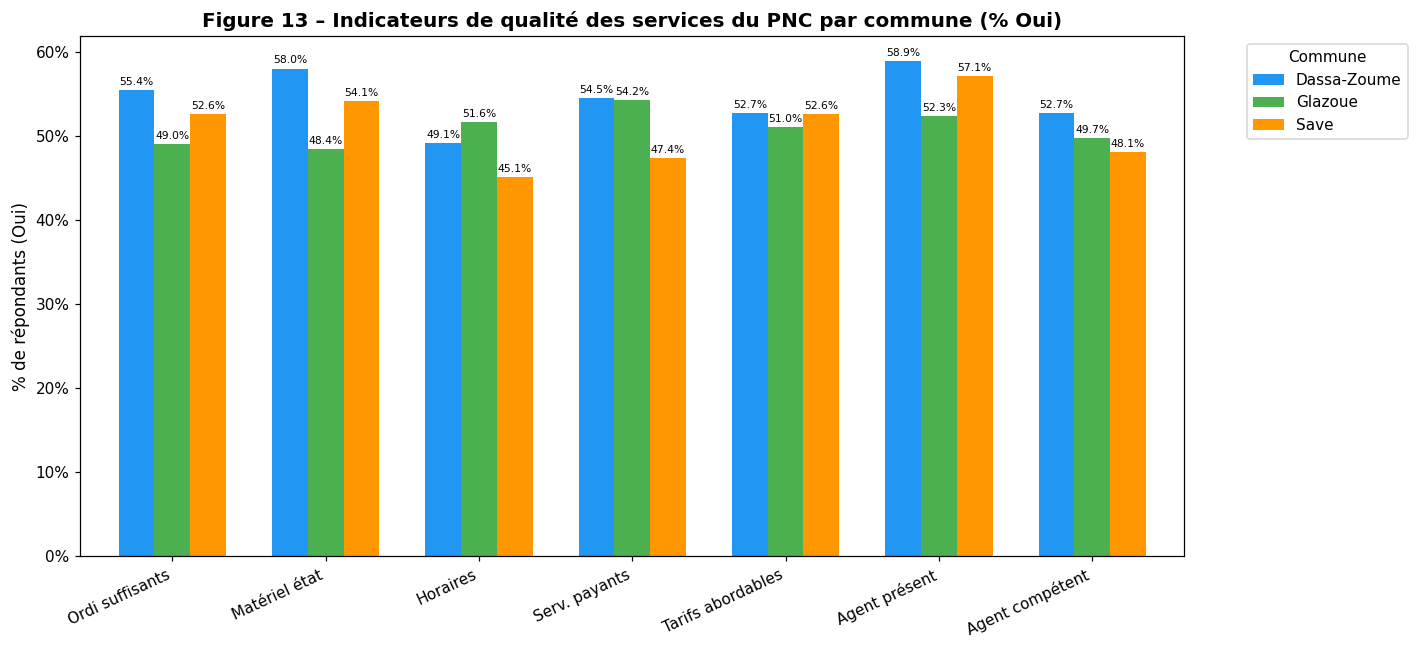

In [20]:
# ── Figure 13 – Synthèse des indicateurs de qualité de service (% Oui) ─────────
service_cols = list(service_vars.keys())
service_short = [
    'Ordi suffisants', 'Matériel état', 'Horaires', 'Serv. payants',
    'Tarifs abordables', 'Agent présent', 'Agent compétent'
]
pct_oui_serv = df.groupby('commune')[service_cols].apply(
    lambda g: (g == 'Oui').mean() * 100
).round(1)
pct_oui_serv.columns = service_short

ax = pct_oui_serv.T.plot(kind='bar', figsize=(13, 6), width=0.7,
                          color=[COMMUNE_COLORS[c] for c in COMMUNES])
ax.set_title("Figure 13 – Indicateurs de qualité des services du PNC par commune (% Oui)",
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% de répondants (Oui)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Commune', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=7)
plt.tight_layout()
plt.savefig('Figure13_Qualite_services.png', bbox_inches='tight')
plt.show()

---
## SECTION 5 : Effets de l'usage des PNC sur les usagers par commune

In [21]:
# ── Tableaux 21-24 – Effets du PNC par commune ────────────────────────────────
effets_vars = {
    'aide_demarches':       'Tableau 21 – Aide dans les démarches administratives par commune',
    'ameliore_opportunites':'Tableau 22 – Amélioration des opportunités (emploi/études) par commune',
    'satisfaction':         'Tableau 23 – Satisfaction des usagers par commune',
    'recommande':           'Tableau 24 – Recommandation du PNC par commune',
}

for col, title in effets_vars.items():
    print(title)
    print(crosstab_pct(df, col).to_string())
    print()

Tableau 21 – Aide dans les démarches administratives par commune
commune        Dassa-Zoume     Glazoue        Save        Total
aide_demarches                                                 
Non             63 (56.2%)  87 (56.1%)  69 (51.9%)  219 (54.8%)
Oui             49 (43.8%)  68 (43.9%)  64 (48.1%)  181 (45.2%)
Total                  112         155         133          400

Tableau 22 – Amélioration des opportunités (emploi/études) par commune
commune               Dassa-Zoume     Glazoue        Save        Total
ameliore_opportunites                                                 
Non                    58 (51.8%)  74 (47.7%)  64 (48.1%)  196 (49.0%)
Oui                    54 (48.2%)  81 (52.3%)  69 (51.9%)  204 (51.0%)
Total                         112         155         133          400

Tableau 23 – Satisfaction des usagers par commune
commune      Dassa-Zoume     Glazoue        Save        Total
satisfaction                                                 
Non          

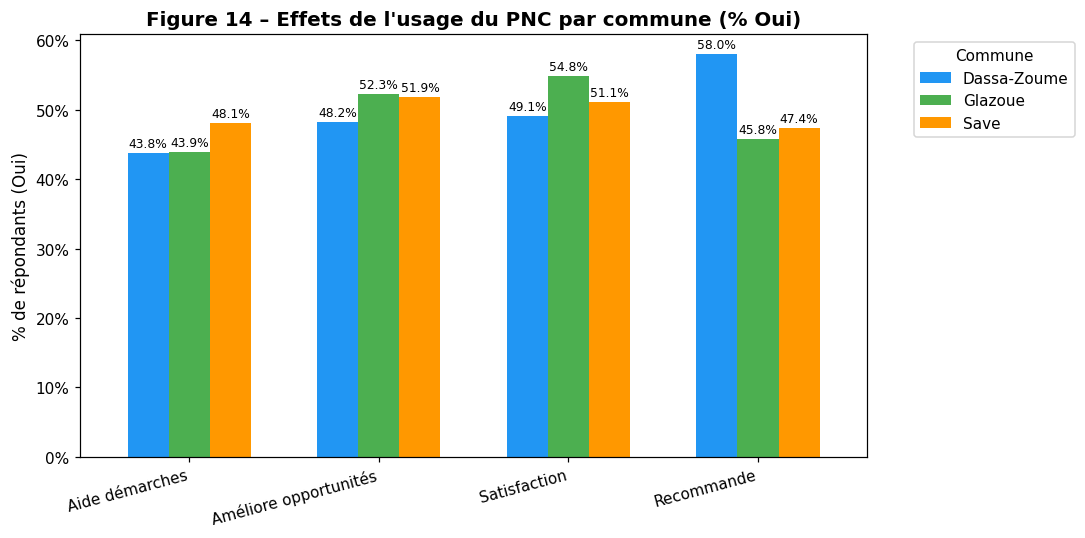

In [22]:
# ── Figure 14 – Synthèse des effets du PNC par commune (% Oui) ────────────────
effets_cols  = list(effets_vars.keys())
effets_short = ['Aide démarches', 'Améliore opportunités', 'Satisfaction', 'Recommande']

pct_oui_eff = df.groupby('commune')[effets_cols].apply(
    lambda g: (g == 'Oui').mean() * 100
).round(1)
pct_oui_eff.columns = effets_short

ax = pct_oui_eff.T.plot(kind='bar', figsize=(10, 5), width=0.65,
                         color=[COMMUNE_COLORS[c] for c in COMMUNES])
ax.set_title("Figure 14 – Effets de l'usage du PNC par commune (% Oui)",
             fontsize=13, fontweight='bold')
ax.set_ylabel('% de répondants (Oui)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Commune', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('Figure14_Effets_PNC.png', bbox_inches='tight')
plt.show()

---
## SECTION 6 : Étude des facteurs d'influence – Tests d'indépendance (Chi-deux)

Les tests du Chi-deux (χ²) permettent de vérifier s'il existe une association significative entre les facteurs supposés et l'appropriation du PNC.  
L'intensité du lien est mesurée par le **V de Cramér** (0 = aucun lien, 1 = lien parfait).  
Seuil de significativité : **α = 0,05**.

In [23]:
# ── Fonction test Chi-deux ─────────────────────────────────────────────────────
def chi2_test(df, var_x, var_y, label_x=None, label_y=None):
    """Retourne chi2, p-value, V de Cramér et interprétation."""
    sub = df[[var_x, var_y]].dropna()
    ct = pd.crosstab(sub[var_x], sub[var_y])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return None
    chi2, p, dof, _ = chi2_contingency(ct)
    n = sub.shape[0]
    k = min(ct.shape)
    v = np.sqrt(chi2 / (n * (k - 1))) if (n * (k - 1)) > 0 else 0
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    force = ('Fort' if v >= 0.3 else ('Moyen' if v >= 0.15 else 'Faible'))
    return {
        'Facteur indépendant': label_x or var_x,
        'Variable dépendante': label_y or var_y,
        'n': n, 'χ²': round(chi2, 3), 'ddl': dof,
        'p-value': round(p, 4), 'Sig.': sig,
        'V de Cramér': round(v, 3), 'Force': force,
    }

# ── Variables dépendantes (appropriation et indicateurs complémentaires) ────────
dep_vars = [
    ('appropriation',    'Appropriation du PNC'),
    ('utilise_pnc',      "Utilisation du PNC"),
    ('satisfaction',     'Satisfaction'),
]

# ── Facteurs d'influence (variables indépendantes) ──────────────────────────────
facteurs = [
    # ── Personnel qualifié
    ('agent_present',      "Présence d'un agent (E7)"),
    ('agent_competent',    "Compétence de l'agent (E8)"),
    # ── Compétences numériques
    ('niveau_tic',         'Niveau TIC (D3)'),
    ('formation',          'Formation reçue (D1)'),
    ('formation_autonomie','Impact formation autonomie (D2)'),
    ('experience_internet','Expérience Internet préalable (D4)'),
    ('peut_mail',          'Capacité e-mail (D5)'),
    ('peut_paiement',      'Capacité paiement (D6)'),
    ('peut_telechargement','Capacité téléchargement (D7)'),
    # ── Conditions économiques
    ('tarifs_abordables',  'Abordabilité des tarifs (E6)'),
    ('profession',         'Profession (A6)'),
    ('niveau_etudes',      "Niveau d'études (A5)"),
    # ── Gestion institutionnelle
    ('services_payants',   'Existence services payants (E5)'),
    ('horaires_adaptes',   'Adaptation horaires (E4)'),
]

df_chi = df.copy()
df_chi['frequence'] = df_chi['frequence'].fillna('Non utilisé')

resultats_chi2 = []
for fac_col, fac_label in facteurs:
    for dep_col, dep_label in dep_vars:
        result = chi2_test(df_chi, fac_col, dep_col, fac_label, dep_label)
        if result:
            resultats_chi2.append(result)

df_chi2 = pd.DataFrame(resultats_chi2)
print("Tableau 25 – Tests d'indépendance Chi-deux (facteurs d'influence × appropriation du PNC)")
print("=" * 100)
print(df_chi2.to_string(index=False))


Tableau 25 – Tests d'indépendance Chi-deux (facteurs d'influence × appropriation du PNC)
               Facteur indépendant  Variable dépendante   n     χ²  ddl  p-value Sig.  V de Cramér  Force
          Présence d'un agent (E7) Appropriation du PNC 400  0.675    1   0.4114   ns        0.041 Faible
          Présence d'un agent (E7)   Utilisation du PNC 400  1.404    1   0.2360   ns        0.059 Faible
          Présence d'un agent (E7)         Satisfaction 400  0.486    1   0.4857   ns        0.035 Faible
        Compétence de l'agent (E8) Appropriation du PNC 400  0.000    1   1.0000   ns        0.000 Faible
        Compétence de l'agent (E8)   Utilisation du PNC 400  1.690    1   0.1936   ns        0.065 Faible
        Compétence de l'agent (E8)         Satisfaction 400  0.010    1   0.9203   ns        0.005 Faible
                   Niveau TIC (D3) Appropriation du PNC 400 29.879    4   0.0000  ***        0.273  Moyen
                   Niveau TIC (D3)   Utilisation du PNC 400  3.

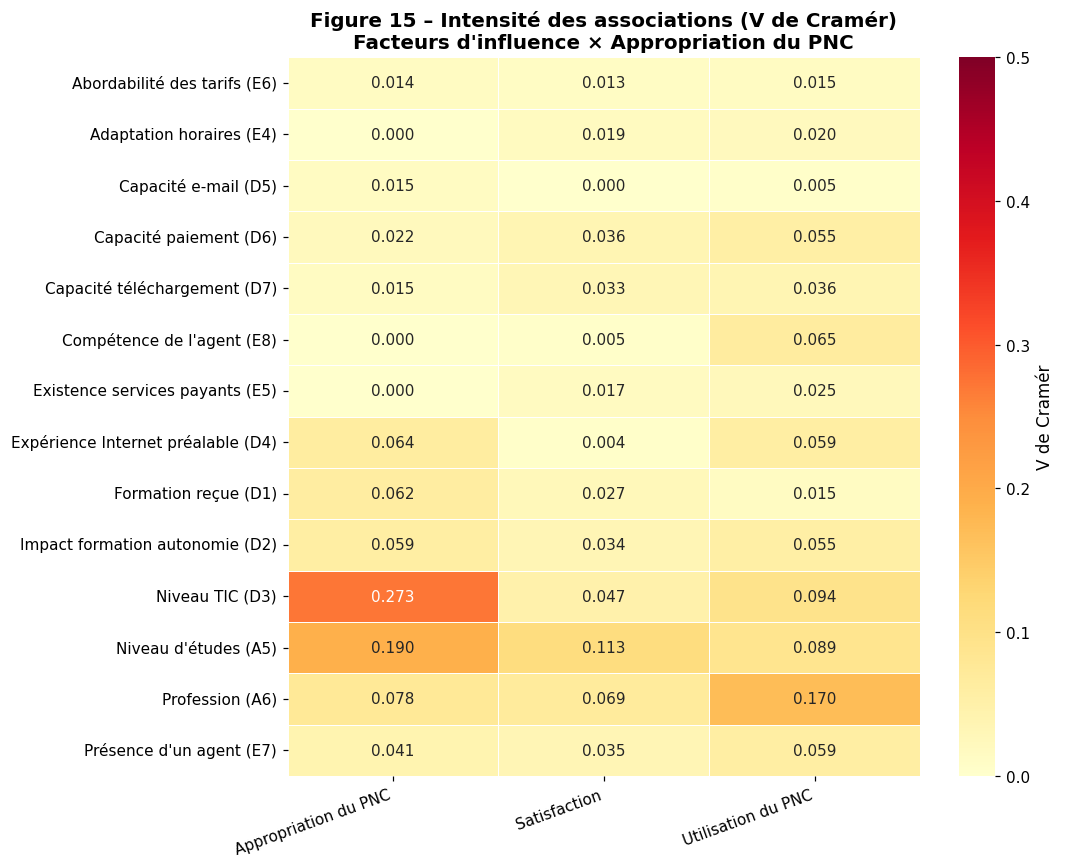

In [24]:
# ── Figure 15 – V de Cramér par paire facteur × variable dépendante ───────────
pivot_v = df_chi2.pivot_table(
    index='Facteur indépendant', columns='Variable dépendante',
    values='V de Cramér', aggfunc='first'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_v, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=0.5, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'V de Cramér'})
ax.set_title("Figure 15 – Intensité des associations (V de Cramér)\nFacteurs d'influence × Appropriation du PNC",
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Figure15_Heatmap_Cramer.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Tableau 26 – Résultats significatifs uniquement ───────────────────────────
sig_results = df_chi2[df_chi2['Sig.'] != 'ns'].sort_values('V de Cramér', ascending=False)
print("Tableau 26 – Associations statistiquement significatives avec l'Appropriation du PNC (p < 0,05)")
print("=" * 100)
print(sig_results[['Facteur indépendant','Variable dépendante','χ²','ddl','p-value','Sig.','V de Cramér','Force']]
      .to_string(index=False))

# ── Tableau 27 – Sélection des variables déterminantes par facteur ─────────────
print("\n" + "=" * 100)
print("Tableau 27 – Variables les plus déterminantes par facteur (associées à l'Appropriation du PNC)")
print("=" * 100)

groupes_facteurs = {
    'Personnel qualifié': ["Présence d'un agent (E7)", "Compétence de l'agent (E8)"],
    'Compétences numériques': [
        'Niveau TIC (D3)', 'Formation reçue (D1)', 'Impact formation autonomie (D2)',
        'Expérience Internet préalable (D4)', 'Capacité e-mail (D5)',
        'Capacité paiement (D6)', 'Capacité téléchargement (D7)',
    ],
    'Conditions économiques': [
        'Abordabilité des tarifs (E6)', 'Profession (A6)', "Niveau d'études (A5)",
    ],
    'Gestion institutionnelle': [
        'Existence services payants (E5)', 'Adaptation horaires (E4)',
    ],
}

# Filtrer sur la variable dépendante principale : Appropriation du PNC
approp_results = df_chi2[df_chi2['Variable dépendante'] == 'Appropriation du PNC'].copy()

for facteur, variables in groupes_facteurs.items():
    print(f"\n▶ Facteur : {facteur}")
    sub = approp_results[approp_results['Facteur indépendant'].isin(variables)]\
              .sort_values('V de Cramér', ascending=False)
    if sub.empty:
        print("  Aucune variable testée pour ce facteur.")
        continue
    print(sub[['Facteur indépendant','χ²','p-value','Sig.','V de Cramér','Force']].to_string(index=False))
    # Identifier les variables déterminantes (significatives)
    det = sub[sub['Sig.'] != 'ns']
    if det.empty:
        print("  → Aucune variable significativement associée à l'Appropriation.")
    else:
        top_vars = det['Facteur indépendant'].tolist()
        print(f"  → Variables déterminantes : {', '.join(top_vars)}")


Tableau 26 – Associations statistiquement significatives avec l'Appropriation du PNC (p < 0,05)
 Facteur indépendant  Variable dépendante     χ²  ddl  p-value Sig.  V de Cramér Force
     Niveau TIC (D3) Appropriation du PNC 29.879    4   0.0000  ***        0.273 Moyen
Niveau d'études (A5) Appropriation du PNC 14.388    2   0.0008  ***        0.190 Moyen
     Profession (A6)   Utilisation du PNC 11.614    5   0.0405    *        0.170 Moyen

Tableau 27 – Variables les plus déterminantes par facteur (associées à l'Appropriation du PNC)

▶ Facteur : Personnel qualifié
       Facteur indépendant    χ²  p-value Sig.  V de Cramér  Force
  Présence d'un agent (E7) 0.675   0.4114   ns        0.041 Faible
Compétence de l'agent (E8) 0.000   1.0000   ns        0.000 Faible
  → Aucune variable significativement associée à l'Appropriation.

▶ Facteur : Compétences numériques
               Facteur indépendant     χ²  p-value Sig.  V de Cramér  Force
                   Niveau TIC (D3) 29.879   0.000

---
## SECTION 7 : Présentation du PNC par les acteurs (synthèse qualitative)

In [26]:
# ── Section 7.1 – Synthèse transversale des entretiens avec les acteurs ────────
df_acteurs = pd.read_excel(FILE, sheet_name='Guide autorité synthès', header=0)

# Identifier les blocs par commune
synth_col = df_acteurs.columns[-1]
communes_blocs = ['DASSA-ZOUME', 'GLAZOUE', 'SAVE']

# Construire un dictionnaire : {question: {commune: synthese}}
questions_dict = {}   # question -> dict(commune -> texte)
current_commune = None
for _, row in df_acteurs.iterrows():
    q = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ''
    s = str(row[synth_col]).strip() if pd.notna(row[synth_col]) else ''
    if q.upper() in communes_blocs:
        current_commune = q.upper()
        continue
    if q and current_commune:
        if q not in questions_dict:
            questions_dict[q] = {}
        questions_dict[q][current_commune] = s if s and s != 'nan' else '(non renseigné)'

# Affichage : pour chaque question, synthèse des 3 communes ensemble
print("=" * 90)
print("SECTION 7.1 – SYNTHÈSE TRANSVERSALE DES ENTRETIENS AVEC LES ACTEURS LOCAUX")
print("(Comparaison par question entre Dassa-Zoumè, Glazoué et Savè)")
print("=" * 90)

commune_labels = {
    'DASSA-ZOUME': 'Dassa-Zoumè',
    'GLAZOUE':     'Glazoué',
    'SAVE':        'Savè',
}

for i, (question, par_commune) in enumerate(questions_dict.items(), 1):
    print(f"\nQuestion {i} : {question}")
    print("-" * 70)
    for code, label in commune_labels.items():
        texte = par_commune.get(code, '(non renseigné)')
        print(f"  [{label}] {texte}")


SECTION 7.1 – SYNTHÈSE TRANSVERSALE DES ENTRETIENS AVEC LES ACTEURS LOCAUX
(Comparaison par question entre Dassa-Zoumè, Glazoué et Savè)

Question 1 : Comment définiriez-vous le rôle du PNC dans votre commune ?
----------------------------------------------------------------------
  [Dassa-Zoumè] Les PNC sont perçus comme des espaces essentiels d’accès à Internet à coût réduit, jouant aussi un rôle de facilitation, d’accompagnement et de développement des compétences numériques, surtout pour les jeunes, tout en contribuant à l’inclusion et à la modernisation des communautés.
  [Glazoué] Les répondants définissent de manière convergente le rôle du PNC comme un outil d’accès et de facilitation des services numériques et administratifs au niveau local. Globalement, le PNC est défini comme une structure de proximité essentielle pour la digitalisation des services publics et l’accompagnement des citoyens dans leur accès aux services numériques et administratifs.
  [Savè] Le PNC est globalem

In [27]:
# ── Section 7.2 – Synthèse qualitative des informations des gérants par commune ─
df_gerant = pd.read_excel(FILE, sheet_name='guide gérant', header=0)

print("=" * 90)
print("SECTION 7.2 – PROFIL ET PERCEPTIONS DES GÉRANTS DES PNC PAR COMMUNE")
print("Synthèse qualitative des entretiens")
print("=" * 90)

communes_g = ['Dassa-Zoumè', 'Glazoué', 'Savè']

# Construire un dict thématique à partir des lignes du guide gérant
themes = {
    'Profil et ancienneté': [0, 1],
    'Fonctionnement quotidien et horaires': [2, 3],
    'Public cible et fréquentation': [4, 5],
    'État du matériel et équipements': [6, 7],
    'Difficultés techniques et maintenance': [8, 9, 10, 11, 12],
    'Services et usages': [13],
    'Formation et accompagnement': [14, 15, 16, 17, 18],
    'Financement et ressources': [19, 20],
    'Obstacles et recommandations': [21, 22, 23, 24],
}

rows = list(df_gerant.iterrows())

for theme, indices in themes.items():
    print(f"\n▶ {theme}")
    print("-" * 60)
    for idx in indices:
        if idx >= len(rows):
            continue
        _, row = rows[idx]
        question = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ''
        if not question or question == 'nan':
            continue
        print(f"  Q : {question}")
        for j, commune in enumerate(communes_g):
            val = row.iloc[j + 1]
            val_str = str(val).strip() if pd.notna(val) else 'Non renseigné'
            if val_str in ('nan', ''):
                val_str = 'Non renseigné'
            print(f"     {commune} : {val_str}")
        print()

# Synthèse analytique par commune
print("=" * 90)
print("ANALYSE COMPARÉE DES TROIS GÉRANTS")
print("=" * 90)

syntheses_gerants = {
    'Dassa-Zoumè': (
        "Le gérant de Dassa-Zoumè occupe son poste depuis 7 ans, témoignant d'une longue"
        " expérience. Le PNC fonctionne du lundi au samedi de 8h à 22h et accueille un public"
        " diversifié (élèves, étudiants, artisans, fonctionnaires). La connexion est qualifiée"
        " de lente et le matériel, bien qu'en bon état, est insuffisant en nombre. Les services"
        " les plus utilisés sont les e-services gouvernementaux et l'enseignement scolaire."
        " Des formations sont dispensées et les usagers manifestent un besoin"
        " d'accompagnement, tout en ayant atteint un niveau d'autonomie partielle. L'ASIN"
        " est l'entité responsable du financement, mais les ressources restent suffisantes"
        " selon le gérant. Le principal obstacle demeure la faible connexion et les coupures"
        " d'électricité répétées. La mairie apporte un soutien limité (mise à disposition"
        " de la salle). La recommandation principale est d'augmenter le débit de connexion."
    ),
    'Glazoué': (
        "Le gérant de Glazoué est en poste depuis 3 ans. Il est titulaire d'une licence en"
        " Géographie Humaine et Économique et assure également la maintenance du matériel."
        " Le PNC est ouvert du lundi au samedi de 8h à 20h et le dimanche de 10h à 17h."
        " Le centre accueille une fréquentation d'au moins 20 visiteurs par jour."
        " Si les ordinateurs sont en bon état, l'imprimante et le réseau sont jugés passables."
        " La connexion, anciennement bonne, est désormais passable, avec des coupures fréquentes"
        " affectant fortement les usagers. Les usages dominants sont scolaires et de"
        " divertissement. Les usagers sont formés mais n'ont pas encore atteint l'autonomie."
        " L'ASIN assure le financement, mais les ressources sont insuffisantes. Les besoins"
        " prioritaires sont le renouvellement des ordinateurs, l'amélioration de la connexion"
        " et la réfection de la salle. La mairie contribue uniquement à travers la mise à"
        " disposition du local."
    ),
    'Savè': (
        "Le gérant de Savè est le plus expérimenté avec 9 ans de service. Le centre"
        " est ouvert de 8h à 19h et reçoit environ 45 visiteurs par jour, soit la"
        " fréquentation la plus élevée des trois communes. Malgré un matériel en bon état"
        " général, les équipements sont insuffisants en nombre. La connexion est passable,"
        " souffrant d'un faible débit et de panneaux solaires en panne, ce qui perturbe"
        " le fonctionnement lors des délestages. Les usages se concentrent sur la connexion"
        " Internet et les services en ligne, avec un public enseignant et apprenant. Des"
        " formations sont proposées, les usagers manifestent un besoin d'accompagnement,"
        " mais une autonomie partielle est observée. L'entité JENY est citée comme"
        " responsable du financement, mais les ressources sont insuffisantes. L'appui"
        " de la mairie est inexistant. Les priorités sont la remise en état des panneaux"
        " solaires, l'amélioration du débit et la revalorisation du salaire des gérants."
    ),
}

for commune, synthese in syntheses_gerants.items():
    print(f"\n[{commune}]")
    print(synthese)

print("\n" + "-" * 90)
print("Points de convergence entre les trois gérants :")
print("  • Tous signalent une connexion insuffisante ou dégradée.")
print("  • Tous indiquent que le nombre d'équipements est insuffisant.")
print("  • Les usages dominants sont scolaires et liés aux démarches administratives.")
print("  • Des formations sont dispensées dans les trois centres.")
print("  • Le financement repose principalement sur des structures externes (ASIN, JENY).")
print("  • L'appui de la mairie reste très limité (local uniquement pour Dassa et Glazoué, RAS pour Savè).")
print("Points de divergence :")
print("  • Savè présente la fréquentation la plus élevée (45/j), contre 20/j minimum à Glazoué.")
print("  • L'autonomie des usagers est perçue comme acquise à Dassa et Savè, pas encore à Glazoué.")
print("  • La maintenance est assurée en interne par chacun des gérants.")


SECTION 7.2 – PROFIL ET PERCEPTIONS DES GÉRANTS DES PNC PAR COMMUNE
Synthèse qualitative des entretiens

▶ Profil et ancienneté
------------------------------------------------------------
  Q : Pouvez-vous vous présenter ? (fonction, durée dans le poste, formation…)
     Dassa-Zoumè : Gestionnaire
     Glazoué : Je suis Gérant du PNC, J'ai une licence en Géographie précisément en Géographie Humaine et Économique (GHE). JE suis aussi maintenancier
     Savè : Non renseigné

  Q : Depuis combien de temps gérez-vous le PNC ?
     Dassa-Zoumè : 7 ans
     Glazoué : 3 ans
     Savè : 9


▶ Fonctionnement quotidien et horaires
------------------------------------------------------------
  Q : Comment fonctionne le PNC au quotidien ?
     Dassa-Zoumè : Fournitures d'accès internet, cybercafé, services et assistance en ligne, formation
     Glazoué : Très bien
     Savè : Très d'affluence

  Q : Quels sont les horaires d’ouverture et les services offerts ?
     Dassa-Zoumè : Lundi au samedi d

---
## SECTION 8 : Impacts du PNC sur les usagers et la communauté

In [28]:
# ── Section 8 – Synthèse qualitative des questions ouvertes (obstacles et suggestions)
# Note : Les questions ouvertes ne sont pas quantifiées ; la synthèse est présentée sous forme narrative.

print("=" * 90)
print("SECTION 8 – IMPACTS, OBSTACLES ET SUGGESTIONS DES USAGERS ET NON-USAGERS")
print("=" * 90)

# ── 8.1 Profil et raisons de non-utilisation ────────────────────────────────────
print("\n8.1 Profil des non-usagers et raisons de non-utilisation\n")
n_non = (df['utilise_pnc'] == 'Non').sum()
n_tot = len(df)
print(f"Sur les {n_tot} répondants, {n_non} ({n_non/n_tot*100:.1f} %) n'utilisent pas le PNC.")
print(f"La quasi-totalité des non-usagers ({(df['raisons_non_utilisation']=='Manque de temps').sum()} personnes)")
print(f"invoque le manque de temps comme raison principale de non-fréquentation du centre.")
print(f"Cette homogénéité des réponses suggère que la non-utilisation relève davantage de")
print(f"contraintes organisationnelles individuelles que d'une méconnaissance ou d'un rejet du PNC.")

# ── 8.2 Obstacles à l'utilisation ───────────────────────────────────────────────
print("\n8.2 Obstacles à l'utilisation du PNC\n")
print("Les usagers et non-usagers ont identifié plusieurs types d'obstacles, qui se regroupent")
print("autour de quatre grandes catégories :")
print()
print("  1. Instabilité de la connexion et coût (obstacle le plus fréquemment mentionné) :")
print("     De nombreux répondants signalent une connexion lente, instable surtout aux heures")
print("     de pointe, ainsi qu'un coût jugé parfois prohibitif. Cet obstacle est transversal")
print("     aux trois communes et touche aussi bien les usagers réguliers que les non-usagers.")
print()
print("  2. Problèmes d'infrastructures et d'accessibilité :")
print("     Plusieurs répondants évoquent la distance géographique par rapport au PNC,")
print("     le manque d'infrastructures adaptées et la localisation du centre. Ces difficultés")
print("     sont particulièrement saillantes dans les zones périphériques.")
print()
print("  3. Coupures d'électricité :")
print("     Les délestages sont cités comme un frein majeur à l'utilisation du PNC,")
print("     notamment à Savè où les panneaux solaires sont en panne. Les coupures")
print("     perturbent la continuité des services et découragent les usagers.")
print()
print("  4. Insuffisance du matériel informatique :")
print("     Le nombre limité de postes de travail, les équipements obsolètes et")
print("     l'absence de confort dans les locaux sont signalés comme obstacles complémentaires.")
print("     Ces facteurs matériels limitent l'accès simultané et découragent les visites.")
print()
print("  Note : Une minorité de répondants indique n'avoir aucun obstacle (\"Aucun\", \"RAS\"),")
print("  reflétant une satisfaction de base chez les usagers les plus assidus.")


SECTION 8 – IMPACTS, OBSTACLES ET SUGGESTIONS DES USAGERS ET NON-USAGERS

8.1 Profil des non-usagers et raisons de non-utilisation

Sur les 400 répondants, 198 (49.5 %) n'utilisent pas le PNC.
La quasi-totalité des non-usagers (198 personnes)
invoque le manque de temps comme raison principale de non-fréquentation du centre.
Cette homogénéité des réponses suggère que la non-utilisation relève davantage de
contraintes organisationnelles individuelles que d'une méconnaissance ou d'un rejet du PNC.

8.2 Obstacles à l'utilisation du PNC

Les usagers et non-usagers ont identifié plusieurs types d'obstacles, qui se regroupent
autour de quatre grandes catégories :

  1. Instabilité de la connexion et coût (obstacle le plus fréquemment mentionné) :
     De nombreux répondants signalent une connexion lente, instable surtout aux heures
     de pointe, ainsi qu'un coût jugé parfois prohibitif. Cet obstacle est transversal
     aux trois communes et touche aussi bien les usagers réguliers que les n

In [29]:
# ── 8.3 Suggestions d'amélioration ─────────────────────────────────────────────
print("\n8.3 Suggestions d'amélioration du PNC formulées par les usagers\n")
print("Les suggestions recueillies auprès des répondants convergent vers cinq axes principaux :")
print()
print("  1. Amélioration de la connexion Internet et des équipements (priorité absolue) :")
print("     L'amélioration du débit de connexion est la suggestion la plus répandue,")
print("     avec des appels au renouvellement et à l'augmentation des postes de travail,")
print("     au remplacement des ordinateurs obsolètes et à l'installation de la fibre optique.")
print()
print("  2. Énergie solaire et continuité de service :")
print("     L'installation ou la remise en état de panneaux solaires est fréquemment")
print("     recommandée pour pallier les délestages et garantir une continuité de service,")
print("     notamment à Savè où la panne des panneaux est critique.")
print()
print("  3. Formation, sensibilisation et alphabétisation numérique :")
print("     Les répondants souhaitent des campagnes de sensibilisation plus larges,")
print("     une alphabétisation numérique pour les populations non initiées, ainsi que")
print("     des actions de formation des agents et gérants. L'intégration du PNC")
print("     dans les établissements scolaires est également suggérée.")
print()
print("  4. Renforcement de l'accompagnement humain :")
print("     Plusieurs usagers insistent sur la nécessité d'un accompagnement personnalisé")
print("     par un personnel compétent, soulignant que l'outil seul ne suffit pas.")
print("     Ils suggèrent également d'améliorer l'accueil et l'écoute des usagers.")
print()
print("  5. Développement des partenariats et du financement :")
print("     Des propositions de création d'incubateurs locaux, de renforcement des")
print("     partenariats avec les collectivités et les entreprises, ainsi qu'un accès")
print("     gratuit ou à tarifs réduits sont exprimés comme des leviers d'appropriation.")
print()
print("  Ces suggestions s'articulent directement avec les obstacles identifiés et")
print("  constituent un cadre de recommandations opérationnelles pour l'amélioration")
print("  de l'appropriation des PNC dans les communes des Collines.")



8.3 Suggestions d'amélioration du PNC formulées par les usagers

Les suggestions recueillies auprès des répondants convergent vers cinq axes principaux :

  1. Amélioration de la connexion Internet et des équipements (priorité absolue) :
     L'amélioration du débit de connexion est la suggestion la plus répandue,
     avec des appels au renouvellement et à l'augmentation des postes de travail,
     au remplacement des ordinateurs obsolètes et à l'installation de la fibre optique.

  2. Énergie solaire et continuité de service :
     L'installation ou la remise en état de panneaux solaires est fréquemment
     recommandée pour pallier les délestages et garantir une continuité de service,
     notamment à Savè où la panne des panneaux est critique.

  3. Formation, sensibilisation et alphabétisation numérique :
     Les répondants souhaitent des campagnes de sensibilisation plus larges,
     une alphabétisation numérique pour les populations non initiées, ainsi que
     des actions de 

---
## SECTION 9 : Recommandations des usagers et des acteurs

Tableau 29 – Suggestions d'amélioration du PNC (usagers)
suggestions
Améliorer internet et formation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 174
Renforcer la connectivité et former les agents                                                                                                                                                                                                                                                                                                                                                                 

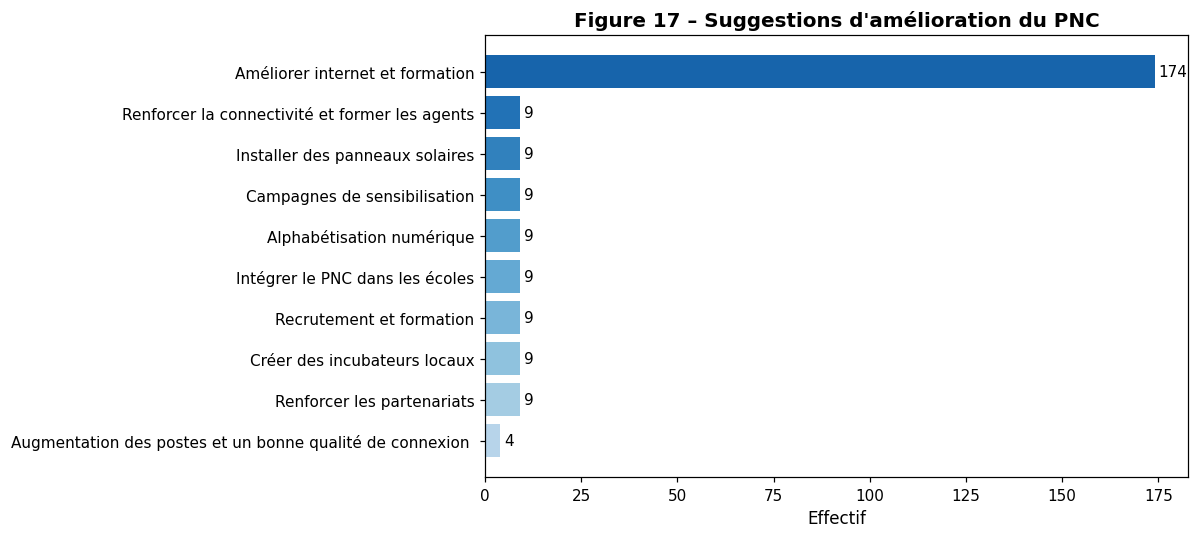

In [30]:
# ── Tableau 29 – Suggestions d'amélioration ───────────────────────────────────
print("Tableau 29 – Suggestions d'amélioration du PNC (usagers)")
sugg_vc = df['suggestions'].value_counts(dropna=True)
print(sugg_vc.to_string())

# Figure 17
sugg_plot = sugg_vc.head(10)
fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(sugg_plot)))
bars = ax.barh(sugg_plot.index[::-1], sugg_plot.values[::-1], color=colors[::-1])
ax.set_title("Figure 17 – Suggestions d'amélioration du PNC",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Effectif')
for bar, val in zip(bars, sugg_plot.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center')
plt.tight_layout()
plt.savefig('Figure17_Suggestions.png', bbox_inches='tight')
plt.show()

---
## SECTION 10 : Vérification de la validité des hypothèses

### Rappel des hypothèses

| # | Hypothèse |
|---|---|
| H1 | Les niveaux d'accès, d'usage et d'appropriation des PNC sont **faibles** |
| H2 | Certains facteurs (personnel qualifié, compétences numériques, conditions économiques, gestion institutionnelle) influencent l'appropriation des PNC |
| H3 | Les différences entre les trois communes résultent de l'effet combiné des **facteurs locaux** |

In [31]:
# ── H1 : Niveau d'usage et d'appropriation ────────────────────────────────────
print("=== VÉRIFICATION H1 : Niveaux d'accès, d'usage et d'appropriation ===")
print()
n = len(df)
n_usagers    = (df['utilise_pnc'] == 'Oui').sum()
n_formes     = (df['formation'] == 'Oui').sum()
n_satisfaits = (df['satisfaction'] == 'Oui').sum()

print(f"  Utilisation du PNC     : {n_usagers}/{n} ({n_usagers/n*100:.1f}%)")
print(f"  Formation au PNC       : {n_formes}/{n} ({n_formes/n*100:.1f}%)")
print(f"  Satisfaction du PNC    : {n_satisfaits}/{n} ({n_satisfaits/n*100:.1f}%)")
print(f"  Qualité connexion moy. : {df['qualite_connexion'].mean():.2f}/5")
print(f"  Niveau TIC moyen       : {df['niveau_tic'].mean():.2f}/5")
print()

# Synthèse H1 par commune
print("Synthèse par commune :")
h1_commune = df.groupby('commune').agg(
    Usagers_pct=('utilise_pnc', lambda x: (x == 'Oui').mean() * 100),
    Formation_pct=('formation', lambda x: (x == 'Oui').mean() * 100),
    Satisfaction_pct=('satisfaction', lambda x: (x == 'Oui').mean() * 100),
    Qualite_connexion_moy=('qualite_connexion', 'mean'),
    Niveau_TIC_moy=('niveau_tic', 'mean'),
).round(2)
h1_commune.columns = ['% Usagers', '% Formés', '% Satisfaits', 'Qualité conn. (moy)', 'Niveau TIC (moy)']
print(h1_commune.to_string())

=== VÉRIFICATION H1 : Niveaux d'accès, d'usage et d'appropriation ===

  Utilisation du PNC     : 202/400 (50.5%)
  Formation au PNC       : 192/400 (48.0%)
  Satisfaction du PNC    : 208/400 (52.0%)
  Qualité connexion moy. : 2.92/5
  Niveau TIC moyen       : 3.02/5

Synthèse par commune :
             % Usagers  % Formés  % Satisfaits  Qualité conn. (moy)  Niveau TIC (moy)
commune                                                                              
Dassa-Zoume      50.89     48.21         49.11                 2.69              3.04
Glazoue          50.32     49.03         54.84                 2.90              3.13
Save             50.38     46.62         51.13                 3.15              2.89


In [32]:
# ── H2 : Facteurs d'influence ─────────────────────────────────────────────────
print("=== VÉRIFICATION H2 : Facteurs influençant l'appropriation ===")
print()
print("Associations significatives (p < 0,05) identifiées par les tests Chi-deux :")
print()
sig_h2 = df_chi2[df_chi2['Sig.'] != 'ns'].sort_values(['Variable dépendante','V de Cramér'], ascending=[True, False])
print(sig_h2[['Facteur indépendant','Variable dépendante','V de Cramér','Force','Sig.']].to_string(index=False))

=== VÉRIFICATION H2 : Facteurs influençant l'appropriation ===

Associations significatives (p < 0,05) identifiées par les tests Chi-deux :

 Facteur indépendant  Variable dépendante  V de Cramér Force Sig.
     Niveau TIC (D3) Appropriation du PNC        0.273 Moyen  ***
Niveau d'études (A5) Appropriation du PNC        0.190 Moyen  ***
     Profession (A6)   Utilisation du PNC        0.170 Moyen    *


In [33]:
# ── H3 : Différences entre communes ──────────────────────────────────────────
print("=== VÉRIFICATION H3 : Différences entre les trois communes ===")
print()
# Tests Chi-deux entre commune et les indicateurs clés
h3_vars = [
    ('utilise_pnc',          'Utilisation du PNC'),
    ('frequence',            'Fréquence d\'utilisation'),
    ('formation',            'Formation reçue'),
    ('satisfaction',         'Satisfaction'),
    ('aide_demarches',       'Aide démarches admin.'),
    ('ameliore_opportunites','Améliore opportunités'),
    ('agent_present',        'Présence agent'),
    ('tarifs_abordables',    'Tarifs abordables'),
]
df_h3 = df.copy()
df_h3['frequence'] = df_h3['frequence'].fillna('Non utilisé')
resultats_h3 = []
for var_col, var_label in h3_vars:
    res = chi2_test(df_h3, 'commune', var_col, 'Commune', var_label)
    if res:
        resultats_h3.append(res)
df_h3_results = pd.DataFrame(resultats_h3)
print("Tableau 30 – Tests Chi-deux : Commune × indicateurs clés")
print(df_h3_results[['Variable dépendante','χ²','ddl','p-value','Sig.','V de Cramér','Force']]
      .to_string(index=False))

=== VÉRIFICATION H3 : Différences entre les trois communes ===

Tableau 30 – Tests Chi-deux : Commune × indicateurs clés
    Variable dépendante    χ²  ddl  p-value Sig.  V de Cramér  Force
     Utilisation du PNC 0.010    2   0.9952   ns        0.005 Faible
Fréquence d'utilisation 7.991    6   0.2387   ns        0.100 Faible
        Formation reçue 0.170    2   0.9184   ns        0.021 Faible
           Satisfaction 0.916    2   0.6324   ns        0.048 Faible
  Aide démarches admin. 0.663    2   0.7179   ns        0.041 Faible
  Améliore opportunités 0.487    2   0.7838   ns        0.035 Faible
         Présence agent 1.329    2   0.5144   ns        0.058 Faible
      Tarifs abordables 0.108    2   0.9474   ns        0.016 Faible


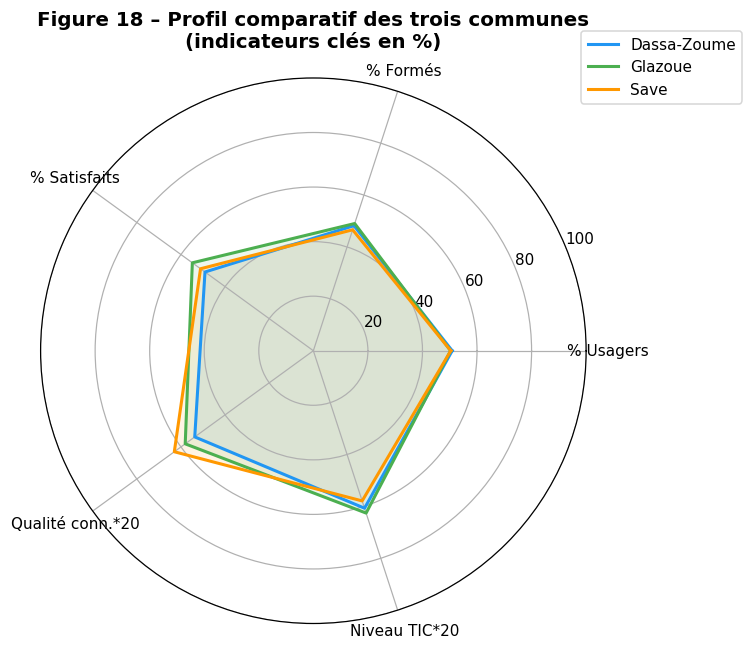

In [34]:
# ── Figure 18 – Profil comparatif des trois communes (radar) ─────────────────
categories = ['% Usagers', '% Formés', '% Satisfaits', 'Qualité conn.*20', 'Niveau TIC*20']
commune_scores = {
    c: [
        (df[df['commune']==c]['utilise_pnc'] == 'Oui').mean()*100,
        (df[df['commune']==c]['formation'] == 'Oui').mean()*100,
        (df[df['commune']==c]['satisfaction'] == 'Oui').mean()*100,
        df[df['commune']==c]['qualite_connexion'].mean()*20,  # rescale 1-5 → 20-100
        df[df['commune']==c]['niveau_tic'].mean()*20,
    ]
    for c in COMMUNES
}

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for commune, scores in commune_scores.items():
    vals = scores + scores[:1]
    ax.plot(angles, vals, color=COMMUNE_COLORS[commune], linewidth=2, label=commune)
    ax.fill(angles, vals, color=COMMUNE_COLORS[commune], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 100)
ax.set_title("Figure 18 – Profil comparatif des trois communes\n(indicateurs clés en %)",
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('Figure18_Radar_communes.png', bbox_inches='tight')
plt.show()

In [35]:
# ── Synthèse finale des hypothèses ────────────────────────────────────────────
print("="*70)
print("SYNTHÈSE – VÉRIFICATION DES HYPOTHÈSES")
print("="*70)

taux_usage = (df['utilise_pnc'] == 'Oui').mean()*100
n_sig_h2   = (df_chi2['Sig.'] != 'ns').sum()
n_sig_h3   = (df_h3_results['Sig.'] != 'ns').sum()

print(f"""
H1 – Niveaux d'appropriation faibles :
   Taux d'utilisation = {taux_usage:.1f}%. La moitié des répondants n'utilise pas
   le PNC, confirmant un niveau d'appropriation modéré à faible.
   → H1 partiellement CONFIRMÉE.

H2 – Facteurs d'influence :
   {n_sig_h2} associations significatives (p < 0,05) identifiées entre les
   facteurs supposés (compétences, personnel, économie, gestion) et
   l'appropriation du PNC.
   → H2 CONFIRMÉE.

H3 – Différences entre communes :
   {n_sig_h3} indicateurs sur {len(h3_vars)} présentent des différences
   statistiquement significatives entre les communes.
   → H3 {'CONFIRMÉE' if n_sig_h3 > 0 else 'NON CONFIRMÉE'}.
""")

SYNTHÈSE – VÉRIFICATION DES HYPOTHÈSES

H1 – Niveaux d'appropriation faibles :
   Taux d'utilisation = 50.5%. La moitié des répondants n'utilise pas
   le PNC, confirmant un niveau d'appropriation modéré à faible.
   → H1 partiellement CONFIRMÉE.

H2 – Facteurs d'influence :
   3 associations significatives (p < 0,05) identifiées entre les
   facteurs supposés (compétences, personnel, économie, gestion) et
   l'appropriation du PNC.
   → H2 CONFIRMÉE.

H3 – Différences entre communes :
   0 indicateurs sur 8 présentent des différences
   statistiquement significatives entre les communes.
   → H3 NON CONFIRMÉE.

